In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint


from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

import pickle
import os

In [2]:
target_train = pd.read_parquet("../data/target_train.parquet")
network_train = pd.read_parquet("../data/network_train.parquet")
weather_train = pd.read_parquet("../data/weather_train.parquet")
weather_test = pd.read_parquet("../data/weather_test.parquet")
network_test = pd.read_parquet("../data/network_test.parquet")

In [3]:


### functions already used for EDA

def flatten_weather_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = ["_".join([str(i) for i in col]) for col in df.columns]
    return df


def interpolate_weather(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_index()
    df = df.interpolate(method="time")
    df = df.ffill()
    return df


def aggregate_weather(df: pd.DataFrame) -> pd.DataFrame:
    ssrd_cols = [c for c in df.columns if c.endswith("ssrd")]
    tcc_cols  = [c for c in df.columns if c.endswith("tcc")]
    temp_cols = [c for c in df.columns if c.endswith("2t")]
    wind_cols = [c for c in df.columns if c.endswith("100ws")]

    flat = pd.DataFrame(index=df.index)
    flat["ssrd_mean"] = df[ssrd_cols].mean(axis=1)
    flat["ssrd_std"]  = df[ssrd_cols].std(axis=1)
    flat["tcc_mean"]  = df[tcc_cols].mean(axis=1)
    flat["tcc_std"]   = df[tcc_cols].std(axis=1)
    flat["temp_mean"] = df[temp_cols].mean(axis=1)
    flat["temp_std"] = df[temp_cols].std(axis=1)
    flat["wind_mean"] = df[wind_cols].mean(axis=1)
    flat["wind_std"]  = df[wind_cols].std(axis=1)

    return flat.bfill().ffill()


def prepare_weather(df: pd.DataFrame) -> pd.DataFrame:
    """Flatten multi-index columns, interpolate missing values, and aggregate to per-hour stats."""
    df = flatten_weather_columns(df)
    df = interpolate_weather(df)
    df = aggregate_weather(df)
    df = df.reset_index().rename(columns={df.index.name or "index": "ds"})
    return df


def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ssrd_lag1"]  = df["ssrd_mean"].shift(1)
    df["ssrd_lag24"] = df["ssrd_mean"].shift(24)
    return df


def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ssrd_roll_3h"]     = df["ssrd_mean"].rolling(3).mean()
    df["ssrd_roll_24h"]    = df["ssrd_mean"].rolling(24).mean()
    df["tcc_roll_6h_std"]  = df["tcc_mean"].rolling(6).std()

    # Add new rolling features for tcc_mean, temp_mean, and wind_mean
    df["tcc_roll_3h_mean"] = df["tcc_mean"].rolling(3).mean()
    df["tcc_roll_24h_mean"] = df["tcc_mean"].rolling(24).mean()
    df["temp_roll_3h_mean"] = df["temp_mean"].rolling(3).mean()
    df["temp_roll_24h_mean"] = df["temp_mean"].rolling(24).mean()
    df["wind_roll_3h_mean"] = df["wind_mean"].rolling(3).mean()
    df["wind_roll_24h_mean"] = df["wind_mean"].rolling(24).mean()
    df["temp_roll_6h_std"]  = df["temp_mean"].rolling(6).std()
    df["wind_roll_6h_std"]  = df["wind_mean"].rolling(6).std()

    return df


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dt = pd.to_datetime(df["ds"])
    df["hour"]      = dt.dt.hour
    df["month"]     = dt.dt.month
    df["hour_sin"]  = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df


def add_solar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ssrd_norm"]       = df["ssrd_mean"] / df["ssrd_mean"].max()
    df["solar_potential"] = df["ssrd_norm"] * (1 - df["tcc_mean"])
    return df


def engineer_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add lags, rolling stats, time encodings, and solar features, then drop NaN rows."""
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = add_time_features(df)



    df = add_solar_features(df)
    return df.dropna()
def prepare_solar_data(target_path: str, weather_path: str, network_path: str) -> pd.DataFrame:
    """Complete pipeline: load + preprocess weather + merge with targets and network features."""
    target_train = pd.read_parquet(target_path)
    weather_train = pd.read_parquet(weather_path)
    network_train = pd.read_parquet(network_path)

    # Interpolate and clip FR_solar_actual before merging
    target_train["FR_solar_actual"] = (
        target_train["FR_solar_actual"]
        .interpolate(method="time")
        .bfill()
        .ffill()
        .clip(lower=0)
    )

    weather_features = engineer_weather_features(prepare_weather(weather_train))

    # Merge with targets and network features
    solar_df = target_train[['FR_solar_actual']].join(weather_features, how='inner').join(network_train, how='inner')

    return solar_df

def prepare_wind_data(target_path: str, weather_path: str) -> pd.DataFrame:
    """Complete pipeline for wind."""
    target_train = pd.read_parquet(target_path)
    weather_train = pd.read_parquet(weather_path)

    weather_features = engineer_weather_features(prepare_weather(weather_train))

    wind_df = target_train[['FR_wind_actual']].join(weather_features)

    return wind_df

def prepare_load_data(target_path: str, weather_path: str, network_path: str) -> pd.DataFrame:
    """Complete pipeline for load (includes network features)."""
    target_train = pd.read_parquet(target_path)
    weather_train = pd.read_parquet(weather_path)
    network_train = pd.read_parquet(network_path)

    weather_features = engineer_weather_features(prepare_weather(weather_train))

    load_df = target_train[['FR_load_actual']].join(weather_features).join(network_train)

    return load_df
##for train test split
def split_data_chronologically(df: pd.DataFrame, test_size: float = 0.2):
    """
    Splits a DataFrame chronologically into training and validation sets,
    and separates features (X) from the target (y).

    Args:
        df (pd.DataFrame): The input DataFrame.
        test_size (float): The proportion of the dataset to include in the validation split.

    Returns:
        tuple: (X_train, y_train, X_valid, y_valid) as pandas DataFrames/Series.
    """
    # Calculate the split point
    split_point = int(len(df) * (1 - test_size))

    # Split the data chronologically
    train = df.iloc[:split_point]
    valid = df.iloc[split_point:]

    # Separate features (X) and target (y)
    X_train = train.drop('FR_solar_actual', axis=1)
    y_train = train['FR_solar_actual']
    X_valid = valid.drop('FR_solar_actual', axis=1)
    y_valid = valid['FR_solar_actual']

    print('Training set shape:', train.shape)
    print('Validation set shape:', valid.shape)

    return X_train, y_train, X_valid, y_valid

##for evaluation
def wmape(y_true, y_pred):
    """Weighted Mean Absolute Percentage Error"""
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

class TimeSeriesEvaluator:
    def compute_standard_metrics(self):
        return {
            'Target': self.target_name,
            'RMSE': np.sqrt(mean_squared_error(self.y_true, self.y_pred)),
            'MAE': mean_absolute_error(self.y_true, self.y_pred),
            'WMAPE': wmape(self.y_true, self.y_pred),
            'R²': r2_score(self.y_true, self.y_pred),
        }

In [4]:
weather_flat = prepare_weather(weather_train)
weather_flat.head()

,ds,ssrd_mean,ssrd_std,tcc_mean,tcc_std,temp_mean,temp_std,wind_mean,wind_std
0,2020-01-01 00:00:00+00:00,0.0,0.0,0.490648,0.425557,3.114028,3.679529,4.431250,2.351552
1,2020-01-01 01:00:00+00:00,0.0,0.0,0.499319,0.416623,2.807910,3.637566,4.399936,2.316953
2,2020-01-01 02:00:00+00:00,0.0,0.0,0.518816,0.414566,2.749704,3.592852,4.380681,2.291575
3,2020-01-01 03:00:00+00:00,0.0,0.0,0.534694,0.409608,2.656238,3.711994,4.475877,2.365991
4,2020-01-01 04:00:00+00:00,0.0,0.0,0.548571,0.407396,2.599818,3.779075,4.508040,2.380406


### Consolidated Weather Feature Engineering

Instead of manually adding lag, rolling, time, and solar features, we can use the `engineer_weather_features` function to automate this process. This function internally calls `add_lag_features`, `add_rolling_features`, `add_time_features`, and `add_solar_features`, and also handles dropping `NaN` rows resulting from these operations.

In [5]:
# Re-apply prepare_weather to get a clean DataFrame (with 'ds' as a column) as input for engineer_weather_features.
weather_flat = prepare_weather(weather_train)

# Now, apply the comprehensive feature engineering function
weather_flat = engineer_weather_features(weather_flat)

# Set 'ds' as the index for consistency with subsequent join operations, and remove the original 'ds' column.
weather_flat = weather_flat.set_index('ds')

print("Engineered weather_flat DataFrame head:")
display(weather_flat.head())
print("\nEngineered weather_flat DataFrame info:")
weather_flat.info()


Engineered weather_flat DataFrame head:


,ssrd_mean,ssrd_std,tcc_mean,tcc_std,temp_mean,temp_std,wind_mean,wind_std,ssrd_lag1,ssrd_lag24,...,temp_roll_6h_std,wind_roll_6h_std,hour,month,hour_sin,hour_cos,month_sin,month_cos,ssrd_norm,solar_potential
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-02 00:00:00+00:00,0.0,0.0,0.591098,0.397544,4.024190,3.424526,3.861214,2.025915,0.0,0.0,...,0.148966,0.083488,0,1,0.000000,1.000000,0.5,0.866025,0.0,0.0
2020-01-02 01:00:00+00:00,0.0,0.0,0.626592,0.391434,3.880080,3.565624,4.081434,2.093133,0.0,0.0,...,0.102429,0.171253,1,1,0.258819,0.965926,0.5,0.866025,0.0,0.0
2020-01-02 02:00:00+00:00,0.0,0.0,0.647933,0.395149,3.885397,3.561708,4.182189,2.126657,0.0,0.0,...,0.076456,0.225824,2,1,0.500000,0.866025,0.5,0.866025,0.0,0.0
2020-01-02 03:00:00+00:00,0.0,0.0,0.652530,0.402927,3.899515,3.605973,4.303050,2.085833,0.0,0.0,...,0.059011,0.250485,3,1,0.707107,0.707107,0.5,0.866025,0.0,0.0
2020-01-02 04:00:00+00:00,0.0,0.0,0.651431,0.406992,3.928852,3.585760,4.358646,2.013896,0.0,0.0,...,0.054884,0.245929,4,1,0.866025,0.500000,0.5,0.866025,0.0,0.0



Engineered weather_flat DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43825 entries, 2020-01-02 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ssrd_mean           43825 non-null  float32
 1   ssrd_std            43825 non-null  float32
 2   tcc_mean            43825 non-null  float32
 3   tcc_std             43825 non-null  float32
 4   temp_mean           43825 non-null  float32
 5   temp_std            43825 non-null  float32
 6   wind_mean           43825 non-null  float32
 7   wind_std            43825 non-null  float32
 8   ssrd_lag1           43825 non-null  float32
 9   ssrd_lag24          43825 non-null  float32
 10  ssrd_roll_3h        43825 non-null  float64
 11  ssrd_roll_24h       43825 non-null  float64
 12  tcc_roll_6h_std     43825 non-null  float64
 13  tcc_roll_3h_mean    43825 non-null  float64
 14  tcc_roll_24h_m

In [6]:
   # Drop original 'hour' and 'month' columns after creating cyclical features
weather_flat = weather_flat.drop(columns=['hour', 'month'])

As showed during EDA it is necessary to compute also the logarithm of ssrd

In [7]:
weather_flat ['ssrd_log'] = np.log1p(weather_flat ['ssrd_mean'])
weather_flat ['ssrd_std_log'] = np.log1p(weather_flat ['ssrd_std'])

c:\Users\cherr\anaconda3\envs\ml\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
weather_flat = weather_flat.drop(columns=['ssrd_mean', 'ssrd_std'])

In [9]:
weather_flat.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43825 entries, 2020-01-02 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tcc_mean            43825 non-null  float32
 1   tcc_std             43825 non-null  float32
 2   temp_mean           43825 non-null  float32
 3   temp_std            43825 non-null  float32
 4   wind_mean           43825 non-null  float32
 5   wind_std            43825 non-null  float32
 6   ssrd_lag1           43825 non-null  float32
 7   ssrd_lag24          43825 non-null  float32
 8   ssrd_roll_3h        43825 non-null  float64
 9   ssrd_roll_24h       43825 non-null  float64
 10  tcc_roll_6h_std     43825 non-null  float64
 11  tcc_roll_3h_mean    43825 non-null  float64
 12  tcc_roll_24h_mean   43825 non-null  float64
 13  temp_roll_3h_mean   43825 non-null  float64
 14  temp_roll_24h_mean  43825 non-null  float64
 15  wind_r

In [10]:
network_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43849 entries, 2020-01-01 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EEX_CARBON               43849 non-null  float32
 1   EEX_COAL                 43849 non-null  float32
 2   EEX_GAS_PEG              43849 non-null  float32
 3   FR_capacity_solar        43849 non-null  float32
 4   FR_capacity_wind         43849 non-null  float32
 5   FR_availability_coal     43849 non-null  float32
 6   FR_availability_gas      43849 non-null  float32
 7   FR_availability_hydro    43849 non-null  float32
 8   FR_availability_nuclear  43849 non-null  float32
dtypes: float32(9)
memory usage: 1.8 MB


Coal price,  gas price, coal availability and wind capacity have no effect on sun shining
FR_capacity_solar matters for this model (more panels = more generation). Therefore I will keep only this column from network_train

In [11]:
network_train = network_train[['FR_capacity_solar']]



These 24 missing rows in weather_flat come from the lag and rolling features  created. These features require 24 hours of history, so the first 24 timestamps cannot be computed and were dropped.

In [12]:
X = weather_flat.join(network_train, how="inner")

In [13]:
target_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43849 entries, 2020-01-01 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   FR_load_actual   43785 non-null  float32
 1   FR_price_actual  43849 non-null  float32
 2   FR_solar_actual  43105 non-null  float32
 3   FR_wind_actual   43705 non-null  float32
dtypes: float32(4)
memory usage: 1.0 MB


FR_solar_actual  43105 indicate that there are 744 rows missing. I will interpolate the missing values

In [14]:


target_train["FR_solar_actual"] = (
    target_train["FR_solar_actual"]
    .interpolate(method="time")
    .bfill()
    .ffill()
    .clip(lower=0)
)

y=target_train[["FR_solar_actual"]]

In [17]:
solar_df=X.join(y, how="inner")
solar_df.head()

,tcc_mean,tcc_std,temp_mean,temp_std,wind_mean,wind_std,ssrd_lag1,ssrd_lag24,ssrd_roll_3h,ssrd_roll_24h,...,hour_sin,hour_cos,month_sin,month_cos,ssrd_norm,solar_potential,ssrd_log,ssrd_std_log,FR_capacity_solar,FR_solar_actual
2020-01-02 00:00:00+00:00,0.591098,0.397544,4.024190,3.424526,3.861214,2.025915,0.0,0.0,0.0,131455.535257,...,0.000000,1.000000,0.5,0.866025,0.0,0.0,0.0,0.0,9440.120117,0.0
2020-01-02 01:00:00+00:00,0.626592,0.391434,3.880080,3.565624,4.081434,2.093133,0.0,0.0,0.0,131455.535257,...,0.258819,0.965926,0.5,0.866025,0.0,0.0,0.0,0.0,9440.209961,0.0
2020-01-02 02:00:00+00:00,0.647933,0.395149,3.885397,3.561708,4.182189,2.126657,0.0,0.0,0.0,131455.535257,...,0.500000,0.866025,0.5,0.866025,0.0,0.0,0.0,0.0,9440.299805,0.0
2020-01-02 03:00:00+00:00,0.652530,0.402927,3.899515,3.605973,4.303050,2.085833,0.0,0.0,0.0,131455.535257,...,0.707107,0.707107,0.5,0.866025,0.0,0.0,0.0,0.0,9440.379883,0.0
2020-01-02 04:00:00+00:00,0.651431,0.406992,3.928852,3.585760,4.358646,2.013896,0.0,0.0,0.0,131455.535257,...,0.866025,0.500000,0.5,0.866025,0.0,0.0,0.0,0.0,9440.469727,0.0


Train Test Split

In [18]:
X_train, y_train, X_valid, y_valid = split_data_chronologically(solar_df, test_size=0.2)

print('\nX_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_valid shape:', X_valid.shape)
print('y_valid shape:', y_valid.shape)

Training set shape: (35060, 29)
Validation set shape: (8765, 29)

X_train shape: (35060, 28)
y_train shape: (35060,)
X_valid shape: (8765, 28)
y_valid shape: (8765,)


In [19]:
X_train.to_parquet('../data/X_train_solar.parquet')
X_valid.to_parquet('../data/X_valid_solar.parquet')
y_train.to_frame().to_parquet('../data/y_train_solar.parquet')
y_valid.to_frame().to_parquet('../data/y_valid_solar.parquet')
print("Solar features saved.")

Solar features saved.


#ML Models

## 1. LGBM

In [22]:
model_1 = LGBMRegressor(
    objective="regression",
    n_estimators=500,           
    learning_rate=0.05,
    num_leaves=32,             
    subsample=0.7,              
    colsample_bytree=0.7,       
    min_child_samples=20,       #  prevent overfitting
    reg_alpha=0.1,              # L1 regularization
    reg_lambda=0.1,             # L2 regularization
    random_state=42
)

In [23]:
model_1.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    callbacks=[]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002532 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6180
[LightGBM] [Info] Number of data points in the train set: 35060, number of used features: 28
[LightGBM] [Info] Start training from score 1880.260090


,boosting_type,'gbdt'
,num_leaves,32
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [24]:
y_pred_train_lgbm = model_1.predict(X_train)

mae_train_lgbm = mean_absolute_error(y_train, y_pred_train_lgbm)
rmse_train_lgbm = np.sqrt(mean_squared_error(y_train, y_pred_train_lgbm))
r2_train_lgbm = r2_score(y_train, y_pred_train_lgbm)
wmape_train_lgbm = np.sum(np.abs(y_train - y_pred_train_lgbm)) / np.sum(y_train)

print("LightGBM Model Performance on Training Data:")
print(f"MAE: {mae_train_lgbm}")
print(f"RMSE: {rmse_train_lgbm}")
print(f"WMAPE: {wmape_train_lgbm:.4f}")
print(f"R²: {r2_train_lgbm}")


LightGBM Model Performance on Training Data:
MAE: 112.656476447222
RMSE: 206.49252920291053
WMAPE: 0.0599
R²: 0.9940250662991106


In [25]:
y_pred = model_1.predict(X_valid)

In [26]:
y_pred = model_1.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
wmape = np.sum(np.abs(y_valid - y_pred)) / np.sum(y_valid)
r2 = r2_score(y_valid, y_pred)

print("LightGBM Model Performance on TestTraining Data:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"WMAPE: {wmape:.4f}")
print(f"R²: {r2}")

LightGBM Model Performance on TestTraining Data:
RMSE: 1458.14
MAE: 801.38
WMAPE: 0.3244
R²: 0.8318496076941144


Overfitting! Test WMAPE of 32% means predictions are off by a third on average — too high for a production model

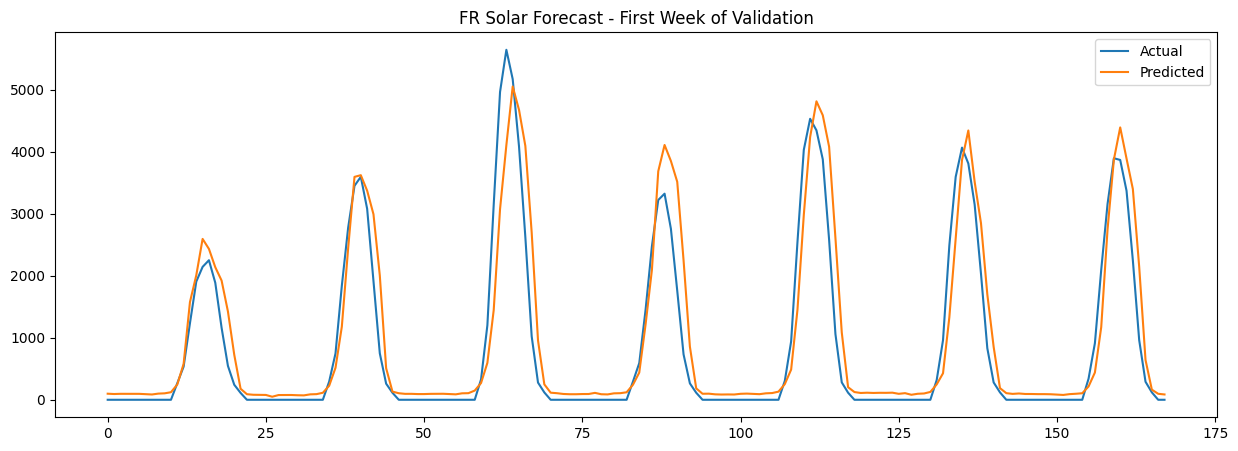

In [100]:


plt.figure(figsize=(15, 5))
plt.plot(y_valid.iloc[:168].values, label="Actual")
plt.plot(y_pred[:168], label="Predicted")
plt.legend()
plt.title("FR Solar Forecast - First Week of Validation")
plt.show()

In [101]:
##check what are the important features

# fi = pd.Series(
#     model_1.feature_importances_,
#     index=X_train.columns
# ).sort_values(ascending=False)

# print(fi.head(20))

## 2. XGBoost Model

In [27]:


model_2 = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=42,
    verbosity=0)

model_2.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [28]:
y_pred_train_xgb = model_2.predict(X_train)

mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
wmape_train_xgb = np.sum(np.abs(y_train - y_pred_train_xgb)) / np.sum(y_train)

print("XGBoost Model Performance on Training Data:")
print(f"MAE: {mae_train_xgb}")
print(f"RMSE: {rmse_train_xgb}")
print(f"WMAPE: {wmape:.4f}")
print(f"R²: {r2_train_xgb}")

XGBoost Model Performance on Training Data:
MAE: 192.1455535888672
RMSE: 351.63484255687746
WMAPE: 0.3244
R²: 0.9826735854148865


In [29]:
y_pred_xgb = model_2.predict(X_valid)

In [30]:


mae_xgb = mean_absolute_error(y_valid, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_xgb))
r2_xgb = r2_score(y_valid, y_pred_xgb)
wmape = np.sum(np.abs(y_valid - y_pred)) / np.sum(y_valid)

print("XGBoost Model Performance on Test Data:")
print(f"MAE: {mae_xgb}")
print(f"RMSE: {rmse_xgb}")

print(f"WMAPE: {wmape:.4f}")
print(f"R²: {r2_xgb}")

XGBoost Model Performance on Test Data:
MAE: 738.2332153320312
RMSE: 1389.8246741945547
WMAPE: 0.3244
R²: 0.8472358584403992


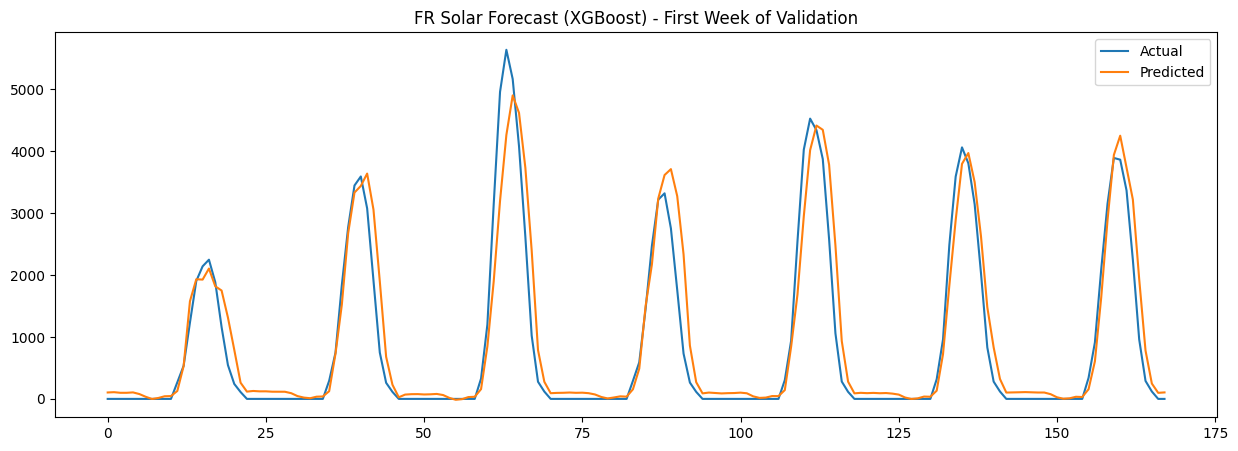

In [106]:
plt.figure(figsize=(15, 5))
plt.plot(y_valid.iloc[:168].values, label="Actual")
plt.plot(y_pred_xgb[:168], label="Predicted")
plt.legend()
plt.title("FR Solar Forecast (XGBoost) - First Week of Validation")
plt.show()

Still overfitting!
Better test MAE (738 vs 801) and test RMSE (1390 vs 1458)
Higher test R² (0.847 vs 0.832)

## Hyperparameter Tuning for XGBoost using RandomizedSearchCV

In [108]:


param_dist = {
    'n_estimators': randint(200, 600),
    'learning_rate': uniform(0.01, 0.05),
    'max_depth': randint(3, 6),
    'subsample': uniform(0.5, 0.35),
    'colsample_bytree': uniform(0.5, 0.35),
    'reg_alpha': uniform(0.5, 2),
    'reg_lambda': uniform(0.5, 2),
    'min_child_weight': randint(8, 20),
}
#Crossvalidation
tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, tree_method='hist'),
    param_distributions=param_dist,
    n_iter=50,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
tuned_rmse = np.sqrt(mean_squared_error(y_valid, best_model.predict(X_valid)))



print(f"Tuned RMSE:    {tuned_rmse:.2f} MW")

print(f"\nBest parameters: {random_search.best_params_}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits


Tuned RMSE:    1406.93 MW

Best parameters: {'colsample_bytree': np.float64(0.8316399490737364), 'learning_rate': np.float64(0.03617043756069616), 'max_depth': 4, 'min_child_weight': 8, 'n_estimators': 200, 'reg_alpha': np.float64(2.2886646516520743), 'reg_lambda': np.float64(1.4403165937199167), 'subsample': np.float64(0.7746292529339924)}


After finding the best parameters,I then train a new XGBoost model with these optimal settings and evaluate its performance on the validation set.

In [109]:
# Train a new model with the best parameters
best_xgb_model = random_search.best_estimator_

# Make predictions on the validation set
y_pred_tuned_xgb = best_xgb_model.predict(X_valid)

# Evaluate the tuned model
mae_tuned_xgb = mean_absolute_error(y_valid, y_pred_tuned_xgb)
rmse_tuned_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_tuned_xgb))
r2_tuned_xgb = r2_score(y_valid, y_pred_tuned_xgb)

print("Tuned XGBoost Model Performance:")
print(f"MAE: {mae_tuned_xgb}")
print(f"RMSE: {rmse_tuned_xgb}")
print(f"R²: {r2_tuned_xgb}")

Tuned XGBoost Model Performance:
MAE: 762.0223999023438
RMSE: 1406.9321234515899
R²: 0.843451976776123


In [110]:
y_pred_train_xgb = best_xgb_model.predict(X_train)

mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)

print("\nTuned XGBoost Model Performance on Training Data:")
print(f"MAE: {mae_train_xgb}")
print(f"RMSE: {rmse_train_xgb}")
print(f"R²: {r2_train_xgb}")


Tuned XGBoost Model Performance on Training Data:
MAE: 212.78248596191406
RMSE: 408.99465155427157
R²: 0.9765598773956299


Still overfitting! The hyperparameter tuning did not help
Train got a bit worse  but test also got worse — which means the tuning didn't reduce overfitting, it just degraded both

Keep XGBOOT without tunning

In [31]:
with open("../models/xgboost_solar_model.pkl", "wb") as f:
    pickle.dump(model_2, f)

print("Model saved to xgboost_solar_model.pkl")

Model saved to xgboost_solar_model.pkl


In [32]:
fi_xgb = pd.Series(
    model_2.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("XGBoost Feature Importances (Top 20):")
print(fi_xgb.head(20))

XGBoost Feature Importances (Top 20):
ssrd_log              0.499120
ssrd_norm             0.238920
ssrd_lag24            0.070518
solar_potential       0.038919
hour_sin              0.030230
temp_roll_6h_std      0.027956
hour_cos              0.022576
FR_capacity_solar     0.019158
ssrd_std_log          0.010326
ssrd_roll_3h          0.007404
ssrd_lag1             0.005917
tcc_roll_3h_mean      0.002692
tcc_mean              0.002465
tcc_std               0.002324
month_sin             0.002006
temp_roll_24h_mean    0.001871
ssrd_roll_24h         0.001863
month_cos             0.001847
temp_roll_3h_mean     0.001794
wind_roll_3h_mean     0.001719
dtype: float32


These importances are very logical for solar power prediction.
Surface Solar Radiation dominates which is physicaly interpretable. The hours are also important parameters which has to do with the solar cycle per day. Temperature and total cloud cover are of lower importance since ssrd already implicitly encodes cloud cover and temperature effects 

# Predict on test dataset

In [33]:
network_test=network_test[['FR_capacity_solar']]

In [34]:
weather_test_flat = prepare_weather(weather_test)
weather_test_flat = engineer_weather_features(weather_test_flat)
weather_test_flat = weather_test_flat.set_index('ds')
weather_test_flat = weather_test_flat.drop(columns=['hour', 'month'])

weather_test_flat['ssrd_log'] = np.log1p(weather_test_flat['ssrd_mean'])
weather_test_flat['ssrd_std_log'] = np.log1p(weather_test_flat['ssrd_std'])
weather_test_flat = weather_test_flat.drop(columns=['ssrd_mean', 'ssrd_std'])

X_test = weather_test_flat.join(network_test, how='inner')

print(X_test.shape)
X_test.head()

(8736, 28)


c:\Users\cherr\anaconda3\envs\ml\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,tcc_mean,tcc_std,temp_mean,temp_std,wind_mean,wind_std,ssrd_lag1,ssrd_lag24,ssrd_roll_3h,ssrd_roll_24h,...,wind_roll_6h_std,hour_sin,hour_cos,month_sin,month_cos,ssrd_norm,solar_potential,ssrd_log,ssrd_std_log,FR_capacity_solar
2025-01-02 00:00:00+00:00,0.901928,0.236845,6.123503,2.876559,9.950920,4.013052,0.0,0.0,0.0,208454.512974,...,0.307684,0.000000,1.000000,0.5,0.866025,0.0,0.0,0.0,0.0,24516.160156
2025-01-02 01:00:00+00:00,0.905479,0.229249,6.088181,2.853961,9.728351,4.218218,0.0,0.0,0.0,208454.512974,...,0.359405,0.258819,0.965926,0.5,0.866025,0.0,0.0,0.0,0.0,24516.830078
2025-01-02 02:00:00+00:00,0.890294,0.241391,5.914766,2.921683,9.379213,4.408256,0.0,0.0,0.0,208454.512974,...,0.430592,0.500000,0.866025,0.5,0.866025,0.0,0.0,0.0,0.0,24517.509766
2025-01-02 03:00:00+00:00,0.902722,0.231170,5.666475,2.897085,9.146226,4.524262,0.0,0.0,0.0,208454.512974,...,0.468451,0.707107,0.707107,0.5,0.866025,0.0,0.0,0.0,0.0,24518.179688
2025-01-02 04:00:00+00:00,0.927873,0.194912,5.427680,2.809566,8.723382,4.521831,0.0,0.0,0.0,208454.512974,...,0.545173,0.866025,0.500000,0.5,0.866025,0.0,0.0,0.0,0.0,24518.859375


In [35]:
y_pred_test = model_2.predict(X_test)
y_pred_test = pd.Series(y_pred_test, index=X_test.index, name="FR_solar_predicted")
print(y_pred_test.shape)
y_pred_test.head()

(8736,)


2025-01-02 00:00:00+00:00    106.744957
2025-01-02 01:00:00+00:00     87.175743
2025-01-02 02:00:00+00:00     39.837486
2025-01-02 03:00:00+00:00     16.031281
2025-01-02 04:00:00+00:00     20.608135
Name: FR_solar_predicted, dtype: float32

In [36]:

os.makedirs("../predictions", exist_ok=True)

solar_predictions = y_pred_test.reset_index()
X_test.to_parquet('../data/X_test_solar.parquet')
solar_predictions.columns = ["datetime", "FR_solar_predicted"]
solar_predictions.to_parquet("../predictions/FR_solar_predicted_2025.parquet", index=False)

print(solar_predictions.shape)
solar_predictions.head()

(8736, 2)


,datetime,FR_solar_predicted
0,2025-01-02 00:00:00+00:00,106.744957
1,2025-01-02 01:00:00+00:00,87.175743
2,2025-01-02 02:00:00+00:00,39.837486
3,2025-01-02 03:00:00+00:00,16.031281
4,2025-01-02 04:00:00+00:00,20.608135
